In [225]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch

In [226]:
rng = np.random.default_rng(seed=42)

## Combine all the batch data

1) Get all the cell line agg data for each batch.
2) Combine all these cell line agg dataframe.
3) Calculate a new agg df for Cell Types.
4) Make a heatmap for this.

In [227]:
batch_1 = pd.read_csv('data/cell_line_agg_data/batch_1_normalised_cellline_agg.csv') 
batch_2 = pd.read_csv('data/cell_line_agg_data/batch_2_normalised_cellline_agg.csv') 
batch_3 = pd.read_csv('data/cell_line_agg_data/batch_3_normalised_cellline_agg.csv') 
all_aggs = pd.concat([batch_1, batch_2, batch_3])
all_aggs


,Cellline ID,Cell Type,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,01-060 C9,PRKN,0.992257,1.211115,0.948110,1.072283,0.825157,0.775770,1.119167,1.057129,...,0.981647,0.921818,1.207045,0.944410,1.018684,1.035499,1.346869,0.922638,0.785347,0.781786
1,09-090 C18,PRKN,0.805924,1.991860,0.570184,2.015875,0.451251,1.166619,2.228253,1.100030,...,1.319117,1.012572,0.831399,1.312066,1.024578,1.400684,1.566051,1.192564,1.351099,1.324170
2,111450-107,Control,1.041170,1.020585,1.036570,0.961944,1.050173,0.935430,0.917591,1.049908,...,1.001272,1.050510,1.084566,1.008583,1.003959,0.938776,0.948410,0.902382,0.989152,0.993611
3,11302-101,Control,1.162849,0.897373,1.214131,0.914393,1.250488,1.088434,0.762622,1.086462,...,1.029565,1.002066,1.029339,1.027459,0.990845,0.983618,0.949800,0.940974,1.000109,1.000759
4,11555-104,SNCA,1.026726,1.032576,1.028388,1.017007,0.998048,0.998562,0.928170,1.032526,...,1.011427,1.050117,1.074948,1.008592,1.009641,1.040218,1.101803,0.944850,0.949845,0.935743
5,11556-110,SNCA,0.678876,1.540514,0.517280,1.629787,0.529243,0.850491,1.939307,0.839419,...,1.064706,0.877200,0.655114,1.023738,1.003829,1.725630,1.730399,1.484879,1.251156,1.166851
6,11557-103,SNCA,0.974789,1.039730,0.954735,0.974147,0.833633,0.899843,0.991837,1.009593,...,0.949380,0.938475,1.096642,0.939549,1.034316,1.015680,1.169987,0.918853,0.778958,0.770864
7,11576-101,LRRK2,0.608552,1.187677,0.499243,1.139370,0.419689,0.760016,1.474019,0.757827,...,0.777899,0.656370,0.618913,0.748380,0.986789,0.802274,1.080572,1.293691,0.831828,0.794592
8,14555-107,LRRK2,0.984581,1.048592,0.978409,1.034724,0.878060,0.838914,0.970467,0.971285,...,0.980055,0.964014,1.113998,0.950058,1.011650,1.082381,1.170492,0.906996,0.791762,0.772975
9,14557-107,LRRK2,0.950798,0.835500,0.991734,0.810744,0.840757,0.756858,0.805323,0.902059,...,1.004798,0.906077,1.062564,0.954552,0.969276,0.933093,1.088473,0.926325,0.750153,0.755356


# Find the aggregate level data for each cell type

In [228]:
all_aggs = all_aggs.drop(columns=['Cellline ID'])
cell_type_agg_df = all_aggs.groupby(['Cell Type']).mean()
cell_type_agg_df

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,0.994426,0.992176,0.995355,0.993453,0.991762,0.999837,0.997608,0.992568,1.032946,1.002771,...,0.995410,0.991583,0.996362,0.993365,1.000534,1.006683,1.009460,1.010046,1.003594,1.001522
LRRK2,0.770155,0.751624,0.786993,0.730363,0.723948,0.662229,0.915761,0.755891,1.532245,0.783372,...,0.939081,0.821777,0.797260,0.879665,0.928010,0.902180,0.921701,1.172384,0.958034,0.935070
PRKN,0.969315,1.067522,0.956944,1.075148,0.941216,0.952448,1.138046,0.984280,0.876548,0.987468,...,0.992720,0.932629,1.005076,0.983447,1.014784,0.966917,1.077402,1.017634,0.941551,0.940435
SNCA,0.884480,1.073109,0.861278,1.144197,0.875940,0.935361,1.286388,0.900996,0.750270,1.091961,...,0.909992,0.899599,0.898983,0.897741,1.015788,0.983534,1.024768,1.125492,0.928137,0.912792


In [229]:
print("cell_line_agg (before): ", cell_type_agg_df.shape)
cell_type_agg_df = cell_type_agg_df.dropna(axis=1)
print("cell_line_agg (after): ", cell_type_agg_df.shape)

cell_line_agg (before):  (4, 1320)
cell_line_agg (after):  (4, 1310)


In [230]:
cell_type_agg_df

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,0.994426,0.992176,0.995355,0.993453,0.991762,0.999837,0.997608,0.992568,1.032946,1.002771,...,0.995410,0.991583,0.996362,0.993365,1.000534,1.006683,1.009460,1.010046,1.003594,1.001522
LRRK2,0.770155,0.751624,0.786993,0.730363,0.723948,0.662229,0.915761,0.755891,1.532245,0.783372,...,0.939081,0.821777,0.797260,0.879665,0.928010,0.902180,0.921701,1.172384,0.958034,0.935070
PRKN,0.969315,1.067522,0.956944,1.075148,0.941216,0.952448,1.138046,0.984280,0.876548,0.987468,...,0.992720,0.932629,1.005076,0.983447,1.014784,0.966917,1.077402,1.017634,0.941551,0.940435
SNCA,0.884480,1.073109,0.861278,1.144197,0.875940,0.935361,1.286388,0.900996,0.750270,1.091961,...,0.909992,0.899599,0.898983,0.897741,1.015788,0.983534,1.024768,1.125492,0.928137,0.912792


### 10 columns were dropped

# Create the heatmap

In [231]:
heatmap_data = cell_type_agg_df
sorted_columns = sorted(heatmap_data.columns, key=lambda x: (re.split(r'\W+', x)[0], re.split(r'\W+', x)[2], re.split(r'\W+', x)[4], re.split(r'\W+', x)[1]))
heatmap_data = heatmap_data[sorted_columns]

### Function to create the labels

In [232]:
regions = []
feature_types = []
star_types = []
organelles = []
ser_types = []

def create_additional_labels(all_columns):
    global regions, feature_types,  star_types, organelles, ser_types

    for col in all_columns:
        col_sections = re.split(r'\W+', col)
        organelle = col_sections[0]
        region = f"{col_sections[2]} {col_sections[3]}"
        feature = col_sections[1]
        star_type = col_sections[4]
        regions.append(region)

        if ('Symmetry' in col_sections) or ('Threshold' in col_sections) or ('Axial' in col_sections) or ('Radial' in col_sections):
            star_types.append(star_type)
            ser_types.append('None')
        elif  ('SER' in col_sections):
            star_types.append('SER')
            if 'Dark' in col_sections:
                ser_types.append('Dark')
            elif 'Ridge' in col_sections:
                ser_types.append('Ridge')
            elif 'Spot' in col_sections:
                ser_types.append('Spot')
            elif 'Edge' in col_sections:
                ser_types.append('Edge')
            elif 'Bright' in col_sections:
                ser_types.append('Bright')
            elif 'Saddle' in col_sections:
                ser_types.append('Saddle')
            elif 'Valley' in col_sections:
                ser_types.append('Valley')
            elif 'Hole' in col_sections:
                ser_types.append('Hole')
            else:
                ser_types.append('None')
        else:
            star_types.append('None')
            ser_types.append('None')
    
        feature_types.append(feature)
        organelles.append(organelle)
    

In [233]:
regions

[]

In [234]:
create_additional_labels(
    sorted_columns
)

In [235]:
print("regions", len(regions))
print("organelles", len(organelles))

regions 1310
organelles 1310


## Function for heatmap generation

In [236]:
def create_heatmap(heatmap_data: pd.DataFrame, clustering: bool):
    global regions, feature_types,  star_types, organelles, ser_types
    # Initialise an organelles array
    organelle_colors = [

    ]

    lut_organelle = {

    }

    for organelle in organelles:
        color = 'Grey'
        if organelle == 'General':
            color = "#ef072a"
        elif organelle == 'Mitochondria':
            color = '#ffe5d9'
        else:
            color = "#6A575C"

        lut_organelle[organelle] = color
        organelle_colors.append(color)

    # Initialise a colours array
    region_colors = [

    ]

    lut = {

    }


    # Initialise a colours array for STAR
    star_colors = [

    ]

    lut_star = {

    }
    for star in star_types:
        if star == 'None':
            star_color = 'Grey'
        elif star == 'Symmetry':
            star_color = '#023e8a'
        elif star == 'Threshold':
            star_color = '#0077b6'
        elif star == 'Axial':
            star_color = '#48cae4'
        elif star == 'Radial':
            star_color = '#caf0f8'
        else:
            star_color = '#457b9d'

        lut_star[star] = star_color
        star_colors.append(star_color)
        


    # Go over each region
    for region in regions:
        if region == 'Nucleus region':
            region_color = 'Blue'
            lut['Nucleus region'] = 'Blue'
        elif region == 'Inner region':
            region_color = 'Red'
            lut['Inner region'] = 'Red'
        elif region == 'Middle region':
            region_color = 'Orange'
            lut['Middle region'] = 'Orange'
        elif region == 'Outer region':
            region_color = 'Yellow'
            lut['Outer region'] = 'Yellow'
        elif region == 'Cell region':
            region_color = 'Green'
            lut['Cell region'] = 'Green'

        lut[region] = region_color
        region_colors.append(region_color)

    # Feature colours
    feature_colours = []
    lut_feature = {

    }
    for feature in feature_types:
        if feature == 'Intensity':
            feature_color = '#335c67'
        elif feature == 'Dimension':
            feature_color = '#ffc300'
        elif feature == 'Spatial':
            feature_color = '#c77dff'
        else:
            feature_color = '#001d3d'

        lut_feature[feature] = feature_color

        feature_colours.append(feature_color)


    # SER colours
    ser_colours = [

    ]

    lut_ser = {

    }

    for ser in ser_types:
        if ser == 'Saddle':
            ser_color = '#f4f1de'
        elif ser == 'Edge':
            ser_color = '#e07a5f'
        elif ser == 'Ridge':
            ser_color = '#3d405b'
        elif ser == 'Valley':
                ser_color = '#81b29a'
        elif ser == 'Hole':
                ser_color = '#f2cc8f'
        elif ser == 'Spot':
            ser_color = '#c77dff'
        elif ser == 'Dark':
            ser_color = '#073b4c'
        elif ser == 'Bright':
            ser_color = '#ef476f'
        else:
            ser_color = '#70798c'

        lut_ser[ser] = ser_color

        ser_colours.append(ser_color)    



    # Figure this legend part out later
    handles = [Patch(facecolor=lut[name]) for name in lut]
    handles_2 = [Patch(facecolor=lut_star[name]) for name in lut_star]
    handles_3 = [Patch(facecolor=lut_feature[name]) for name in lut_feature]
    handles_4 = [Patch(facecolor=lut_organelle[name]) for name in lut_organelle]
    handles_5 = [Patch(facecolor=lut_ser[name]) for name in lut_ser]
    col_colors=[organelle_colors, region_colors, star_colors, ser_colours, feature_colours]
    print(col_colors)

    g= None
    if clustering:
        g = sns.clustermap(
            heatmap_data,
            cmap='vlag',
            center=0,
            figsize=(15, 12),
            row_cluster=False,
            col_cluster=clustering,
            z_score=1,
            method='ward',
            metric='euclidean',
            col_colors=[organelle_colors, region_colors, star_colors, ser_colours, feature_colours]
        )
    else:
        g = sns.clustermap(
                    heatmap_data,
                    cmap='vlag',
                    center=0,
                    figsize=(15, 12),
                    row_cluster=False,
                    col_cluster=False,
                    z_score=1,
                    col_colors=[organelle_colors, region_colors, star_colors, ser_colours, feature_colours]
                )


    # Get the position of the heatmap
    pos = g.ax_heatmap.get_position()

    # Define how much gap we want to add
    gap = 0.02 

    g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

    ax= plt.gca()
    # First Legend (Organelle)
    leg1 = plt.legend(handles_4, lut_organelle, title='Organelle',
                    bbox_to_anchor=(1.02, 1.0), bbox_transform=plt.gcf().transFigure, loc='upper left')
    ax.add_artist(leg1) 

    # Second Legend (Region) - Shifted down vertically
    leg2 = plt.legend(handles, lut, title='Region',
                    bbox_to_anchor=(1.02, 0.75), bbox_transform=plt.gcf().transFigure, loc='upper left')
    ax.add_artist(leg2)

    # Third Legend (STAR) - Shifted further down 
    leg3 = plt.legend(handles_2, lut_star, title='STAR',
                    bbox_to_anchor=(1.02, 0.50), bbox_transform=plt.gcf().transFigure, loc='lower left')
    ax.add_artist(leg3)

    # SER
    leg5 = plt.legend(handles_5, lut_ser, title='SER',
                    bbox_to_anchor=(1.02, 0.25), bbox_transform=plt.gcf().transFigure, loc='lower left')
    ax.add_artist(leg5)

    #  Fifth Legend (STAR) - Placed at the bottom right corner
    leg4 = plt.legend(handles_3, lut_feature, title='Feature',
                    bbox_to_anchor=(1.02, 0.0), bbox_transform=plt.gcf().transFigure, loc='upper left')


[['#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C

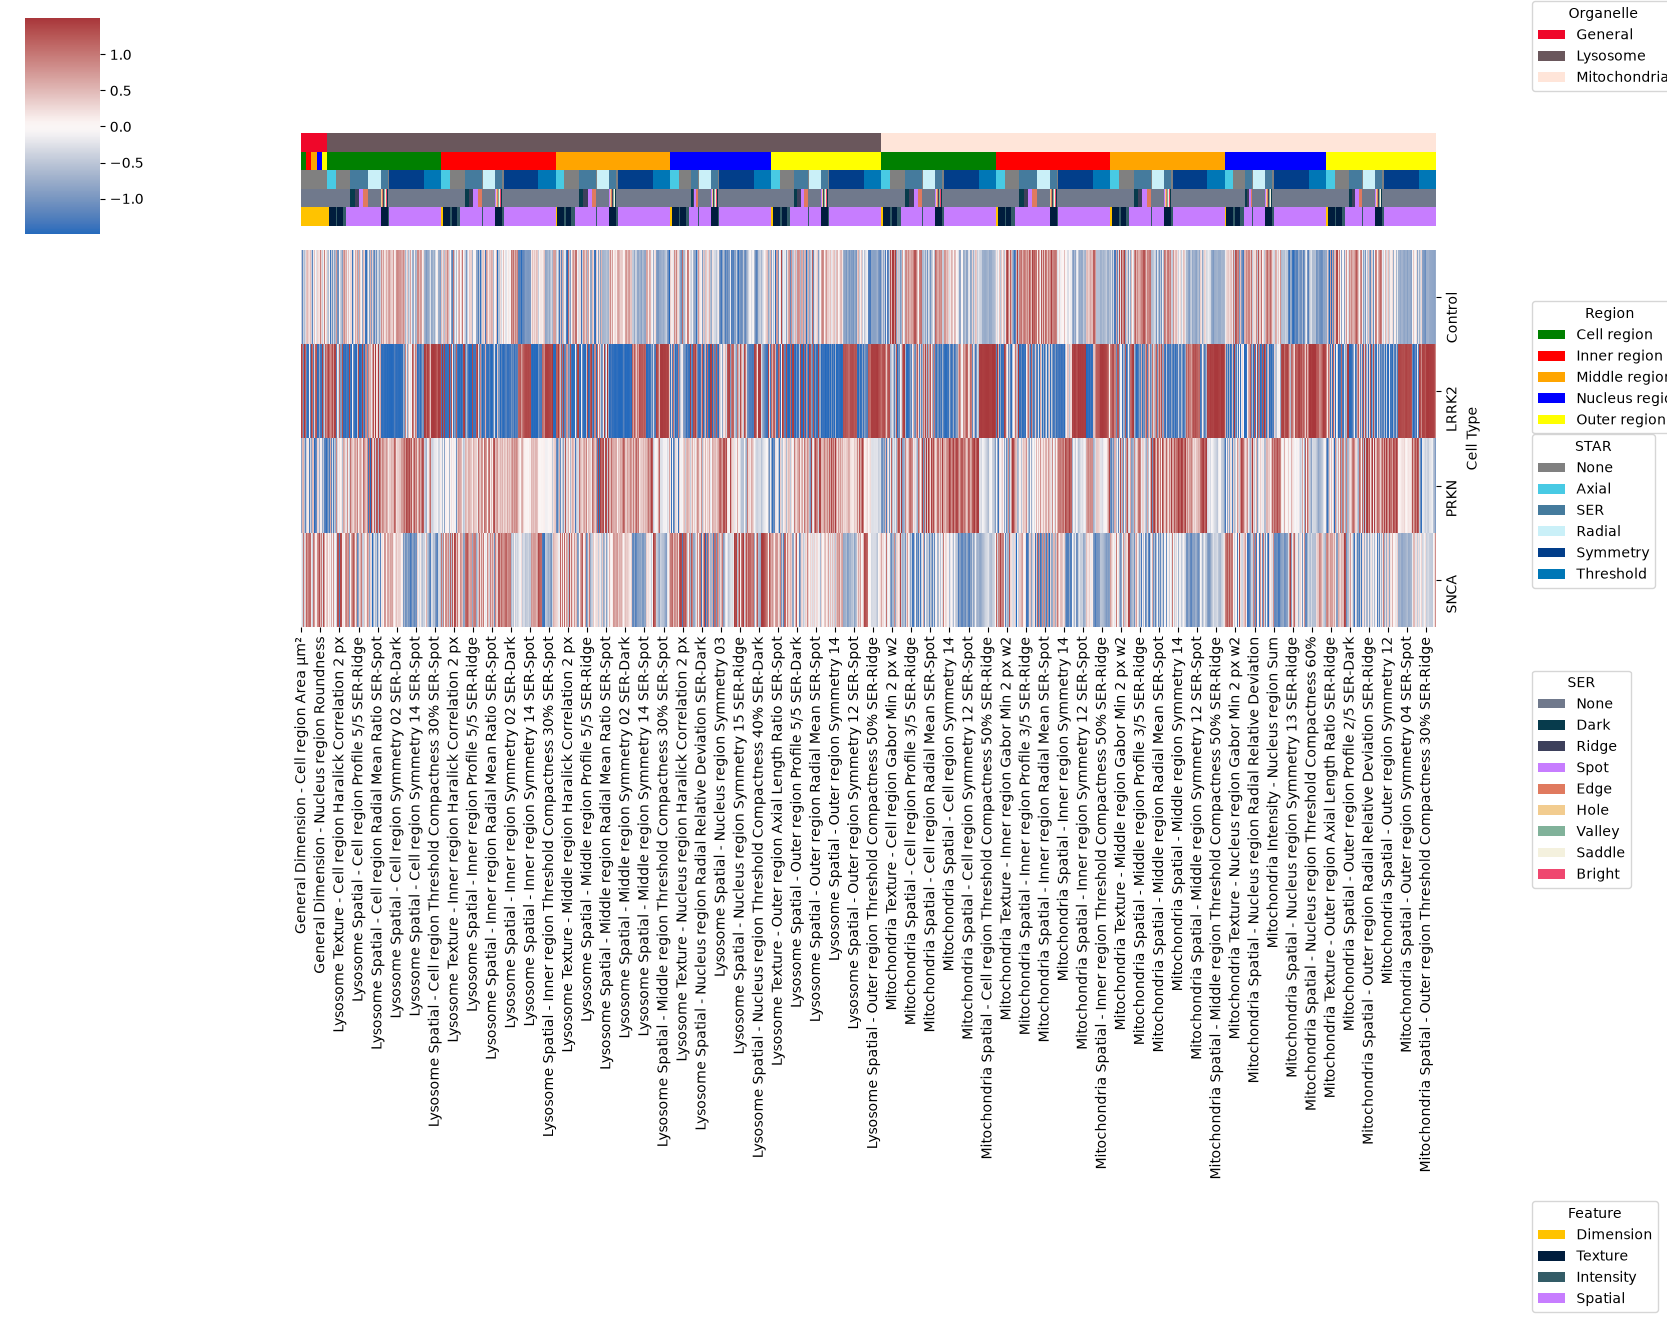

In [237]:
create_heatmap(
    heatmap_data,
    False
)

[['#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#ef072a', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C', '#6A575C

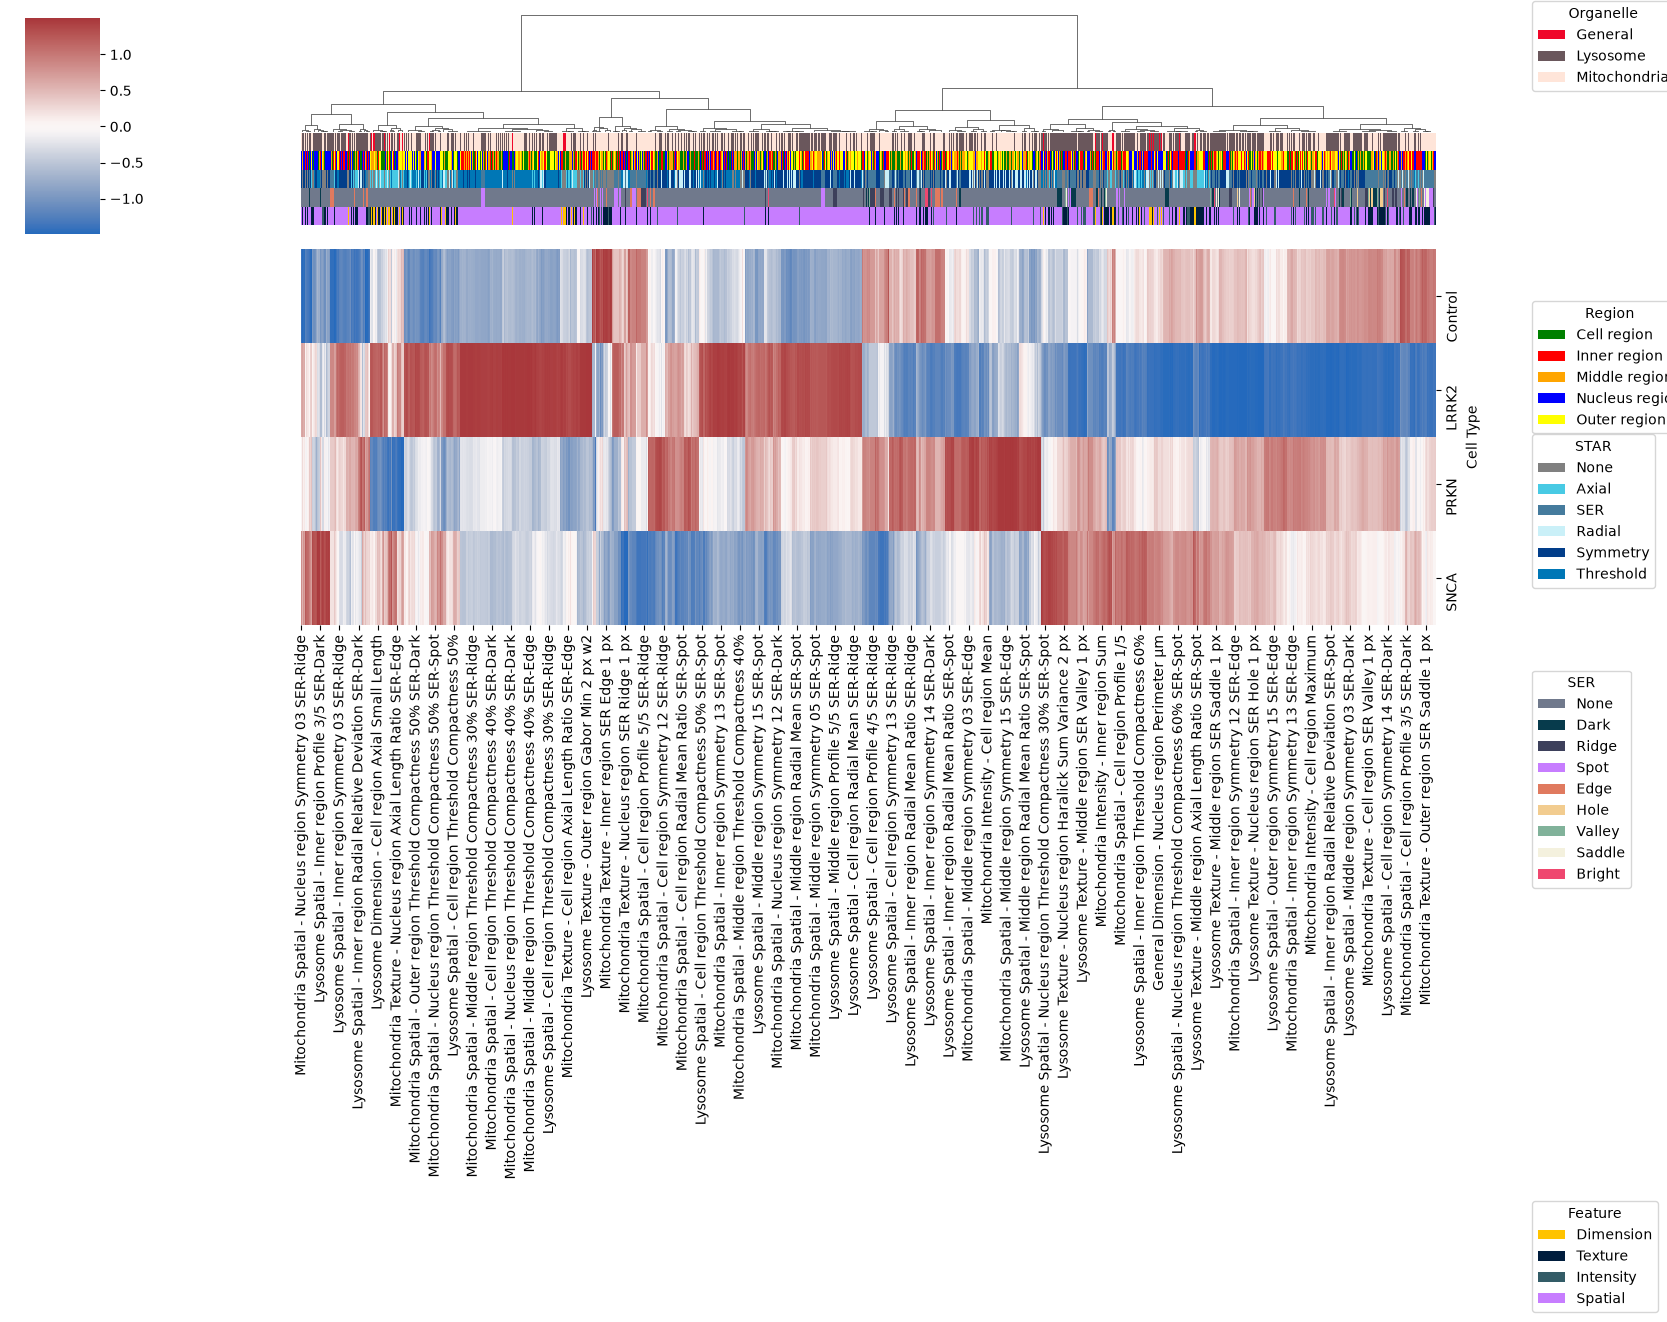

In [238]:
create_heatmap(
    heatmap_data,
    True
)

# ANOVA test to find the most important columns

# ANOVA test

## Calculate the total variance for each column

In [271]:
batch_1 = pd.read_csv('data/cell_line_agg_data/batch_1_normalised_cellline_agg.csv') 
batch_2 = pd.read_csv('data/cell_line_agg_data/batch_2_normalised_cellline_agg.csv') 
batch_3 = pd.read_csv('data/cell_line_agg_data/batch_3_normalised_cellline_agg.csv') 
counts = pd.concat([batch_1, batch_2, batch_3])
counts = counts.drop(columns=['Cellline ID'])
counts = counts.dropna(axis=1)

In [272]:
counts

,Cell Type,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,PRKN,0.992257,1.211115,0.948110,1.072283,0.825157,0.775770,1.119167,1.057129,1.740250,...,0.981647,0.921818,1.207045,0.944410,1.018684,1.035499,1.346869,0.922638,0.785347,0.781786
1,PRKN,0.805924,1.991860,0.570184,2.015875,0.451251,1.166619,2.228253,1.100030,-1.653118,...,1.319117,1.012572,0.831399,1.312066,1.024578,1.400684,1.566051,1.192564,1.351099,1.324170
2,Control,1.041170,1.020585,1.036570,0.961944,1.050173,0.935430,0.917591,1.049908,1.224192,...,1.001272,1.050510,1.084566,1.008583,1.003959,0.938776,0.948410,0.902382,0.989152,0.993611
3,Control,1.162849,0.897373,1.214131,0.914393,1.250488,1.088434,0.762622,1.086462,1.646812,...,1.029565,1.002066,1.029339,1.027459,0.990845,0.983618,0.949800,0.940974,1.000109,1.000759
4,SNCA,1.026726,1.032576,1.028388,1.017007,0.998048,0.998562,0.928170,1.032526,1.618743,...,1.011427,1.050117,1.074948,1.008592,1.009641,1.040218,1.101803,0.944850,0.949845,0.935743
5,SNCA,0.678876,1.540514,0.517280,1.629787,0.529243,0.850491,1.939307,0.839419,-0.982816,...,1.064706,0.877200,0.655114,1.023738,1.003829,1.725630,1.730399,1.484879,1.251156,1.166851
6,SNCA,0.974789,1.039730,0.954735,0.974147,0.833633,0.899843,0.991837,1.009593,1.875641,...,0.949380,0.938475,1.096642,0.939549,1.034316,1.015680,1.169987,0.918853,0.778958,0.770864
7,LRRK2,0.608552,1.187677,0.499243,1.139370,0.419689,0.760016,1.474019,0.757827,0.194989,...,0.777899,0.656370,0.618913,0.748380,0.986789,0.802274,1.080572,1.293691,0.831828,0.794592
8,LRRK2,0.984581,1.048592,0.978409,1.034724,0.878060,0.838914,0.970467,0.971285,2.239874,...,0.980055,0.964014,1.113998,0.950058,1.011650,1.082381,1.170492,0.906996,0.791762,0.772975
9,LRRK2,0.950798,0.835500,0.991734,0.810744,0.840757,0.756858,0.805323,0.902059,2.863233,...,1.004798,0.906077,1.062564,0.954552,0.969276,0.933093,1.088473,0.926325,0.750153,0.755356


In [251]:
no_cell_type = counts.drop(columns=['Cell Type'])
whole_variance = no_cell_type.agg(['var'])
whole_variance

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
var,0.052863,0.083195,0.068942,0.09624,0.067972,0.048117,0.192121,0.042822,0.693656,0.053962,...,0.018545,0.015403,0.045295,0.019735,0.004012,0.056759,0.061061,0.032696,0.015473,0.014169


## Calculate the total variance per group

In [273]:
cell_type_cell_line = counts[['Cell Type']]
cell_type_var = counts.groupby(['Cell Type']).agg(['var'])
cell_type_var

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
,var,var,var,var,var,var,var,var,var,var,...,var,var,var,var,var,var,var,var,var,var
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,0.014496,0.012201,0.019654,0.010990,0.025522,0.006104,0.046072,0.009726,0.141000,0.036650,...,0.002784,0.004183,0.005675,0.003488,0.000243,0.008309,0.010125,0.010949,0.001968,0.002582
LRRK2,0.103299,0.098521,0.125238,0.104246,0.095355,0.092447,0.047436,0.084243,0.565289,0.024059,...,0.032612,0.031742,0.110050,0.030417,0.011479,0.084561,0.071306,0.067697,0.018693,0.015675
PRKN,0.039936,0.147840,0.067917,0.143050,0.080646,0.025157,0.320043,0.029041,1.139832,0.046473,...,0.019660,0.007201,0.024004,0.021206,0.000682,0.035581,0.054270,0.011830,0.026059,0.023829
SNCA,0.046646,0.046204,0.069056,0.073385,0.058041,0.015708,0.372101,0.030260,0.929882,0.075504,...,0.023789,0.008612,0.035056,0.023158,0.000174,0.124781,0.130059,0.034999,0.020210,0.017238


In [274]:
# Calculate the ratio of min to max variance per column
def min_max_ratio(df):
    if df.min() == 0:
        return False
    
    return df.max()/df.min() < 4

min_max_var = pd.DataFrame(cell_type_var.agg(min_max_ratio), columns=['ANOVA safe'])
min_max_var

,,ANOVA safe
Lysosome Intensity - Nucleus region Mean,var,False
Lysosome Intensity - Nucleus region StdDev,var,False
Lysosome Intensity - Nucleus region Median,var,False
Lysosome Intensity - Nucleus region Maximum,var,False
Lysosome Intensity - Nucleus region Minimum,var,True
...,...,...
Mitochondria Texture - Outer region Haralick Contrast 2 px,var,False
Mitochondria Texture - Outer region Haralick Sum Variance 2 px,var,False
Mitochondria Texture - Outer region Haralick Homogeneity 2 px,var,False
Mitochondria Texture - Outer region Gabor Min 2 px w2,var,False


In [334]:
anova_safe_columns = min_max_var['ANOVA safe'].tolist()
print(anova_safe_columns.count(True))

# Cell Types
cell_types = counts['Cell Type']
no_cell_types = counts.drop(columns=['Cell Type'])

# STORE the columns that are ANOVA safe
anova_safe_data = no_cell_types.loc[:, anova_safe_columns]
anova_safe_data = no_cell_types

123


In [335]:
anova_safe_data

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,0.992257,1.211115,0.948110,1.072283,0.825157,0.775770,1.119167,1.057129,1.740250,0.699530,...,0.981647,0.921818,1.207045,0.944410,1.018684,1.035499,1.346869,0.922638,0.785347,0.781786
1,0.805924,1.991860,0.570184,2.015875,0.451251,1.166619,2.228253,1.100030,-1.653118,1.339069,...,1.319117,1.012572,0.831399,1.312066,1.024578,1.400684,1.566051,1.192564,1.351099,1.324170
2,1.041170,1.020585,1.036570,0.961944,1.050173,0.935430,0.917591,1.049908,1.224192,0.812629,...,1.001272,1.050510,1.084566,1.008583,1.003959,0.938776,0.948410,0.902382,0.989152,0.993611
3,1.162849,0.897373,1.214131,0.914393,1.250488,1.088434,0.762622,1.086462,1.646812,0.879115,...,1.029565,1.002066,1.029339,1.027459,0.990845,0.983618,0.949800,0.940974,1.000109,1.000759
4,1.026726,1.032576,1.028388,1.017007,0.998048,0.998562,0.928170,1.032526,1.618743,0.886159,...,1.011427,1.050117,1.074948,1.008592,1.009641,1.040218,1.101803,0.944850,0.949845,0.935743
5,0.678876,1.540514,0.517280,1.629787,0.529243,0.850491,1.939307,0.839419,-0.982816,1.185695,...,1.064706,0.877200,0.655114,1.023738,1.003829,1.725630,1.730399,1.484879,1.251156,1.166851
6,0.974789,1.039730,0.954735,0.974147,0.833633,0.899843,0.991837,1.009593,1.875641,0.836633,...,0.949380,0.938475,1.096642,0.939549,1.034316,1.015680,1.169987,0.918853,0.778958,0.770864
7,0.608552,1.187677,0.499243,1.139370,0.419689,0.760016,1.474019,0.757827,0.194989,1.010745,...,0.777899,0.656370,0.618913,0.748380,0.986789,0.802274,1.080572,1.293691,0.831828,0.794592
8,0.984581,1.048592,0.978409,1.034724,0.878060,0.838914,0.970467,0.971285,2.239874,0.776451,...,0.980055,0.964014,1.113998,0.950058,1.011650,1.082381,1.170492,0.906996,0.791762,0.772975
9,0.950798,0.835500,0.991734,0.810744,0.840757,0.756858,0.805323,0.902059,2.863233,0.721952,...,1.004798,0.906077,1.062564,0.954552,0.969276,0.933093,1.088473,0.926325,0.750153,0.755356


## Use the stats module to calculate the anova test for each column

In [336]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [337]:
anova_safe_columns = anova_safe_data.columns
print(anova_safe_columns)

anova_safe_data = pd.concat([anova_safe_data, cell_types], axis=1)
anova_safe_data

Index(['Lysosome Intensity - Nucleus region Mean',
       'Lysosome Intensity - Nucleus region StdDev',
       'Lysosome Intensity - Nucleus region Median',
       'Lysosome Intensity - Nucleus region Maximum',
       'Lysosome Intensity - Nucleus region Minimum',
       'Lysosome Intensity - Nucleus region Sum',
       'Lysosome Intensity - Nucleus region CV [%]',
       'Lysosome Intensity - Nucleus region Quantile 90%',
       'Lysosome Intensity - Nucleus region Contrast',
       'General Dimension - Nucleus region Area µm²',
       ...
       'Mitochondria Texture - Outer region SER Valley 1 px',
       'Mitochondria Texture - Outer region SER Saddle 1 px',
       'Mitochondria Texture - Outer region SER Bright 1 px',
       'Mitochondria Texture - Outer region SER Dark 1 px',
       'Mitochondria Texture - Outer region Haralick Correlation 2 px',
       'Mitochondria Texture - Outer region Haralick Contrast 2 px',
       'Mitochondria Texture - Outer region Haralick Sum Variance 

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2,Cell Type
0,0.992257,1.211115,0.948110,1.072283,0.825157,0.775770,1.119167,1.057129,1.740250,0.699530,...,0.921818,1.207045,0.944410,1.018684,1.035499,1.346869,0.922638,0.785347,0.781786,PRKN
1,0.805924,1.991860,0.570184,2.015875,0.451251,1.166619,2.228253,1.100030,-1.653118,1.339069,...,1.012572,0.831399,1.312066,1.024578,1.400684,1.566051,1.192564,1.351099,1.324170,PRKN
2,1.041170,1.020585,1.036570,0.961944,1.050173,0.935430,0.917591,1.049908,1.224192,0.812629,...,1.050510,1.084566,1.008583,1.003959,0.938776,0.948410,0.902382,0.989152,0.993611,Control
3,1.162849,0.897373,1.214131,0.914393,1.250488,1.088434,0.762622,1.086462,1.646812,0.879115,...,1.002066,1.029339,1.027459,0.990845,0.983618,0.949800,0.940974,1.000109,1.000759,Control
4,1.026726,1.032576,1.028388,1.017007,0.998048,0.998562,0.928170,1.032526,1.618743,0.886159,...,1.050117,1.074948,1.008592,1.009641,1.040218,1.101803,0.944850,0.949845,0.935743,SNCA
5,0.678876,1.540514,0.517280,1.629787,0.529243,0.850491,1.939307,0.839419,-0.982816,1.185695,...,0.877200,0.655114,1.023738,1.003829,1.725630,1.730399,1.484879,1.251156,1.166851,SNCA
6,0.974789,1.039730,0.954735,0.974147,0.833633,0.899843,0.991837,1.009593,1.875641,0.836633,...,0.938475,1.096642,0.939549,1.034316,1.015680,1.169987,0.918853,0.778958,0.770864,SNCA
7,0.608552,1.187677,0.499243,1.139370,0.419689,0.760016,1.474019,0.757827,0.194989,1.010745,...,0.656370,0.618913,0.748380,0.986789,0.802274,1.080572,1.293691,0.831828,0.794592,LRRK2
8,0.984581,1.048592,0.978409,1.034724,0.878060,0.838914,0.970467,0.971285,2.239874,0.776451,...,0.964014,1.113998,0.950058,1.011650,1.082381,1.170492,0.906996,0.791762,0.772975,LRRK2
9,0.950798,0.835500,0.991734,0.810744,0.840757,0.756858,0.805323,0.902059,2.863233,0.721952,...,0.906077,1.062564,0.954552,0.969276,0.933093,1.088473,0.926325,0.750153,0.755356,LRRK2


In [338]:
signifcant_columns = []

# Overall significantly affected columns

In [339]:
for col in anova_safe_columns:
    # Extract individual groups
    control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control'][col]
    lrrk2 = anova_safe_data[anova_safe_data['Cell Type'] == 'LRRK2'][col]
    prrkn = anova_safe_data[anova_safe_data['Cell Type'] == 'PRKN'][col]
    snca = anova_safe_data[anova_safe_data['Cell Type'] == 'SNCA'][col]

    # Perform ANOVA
    if col != 'Cell Type':
        val = stats.kruskal(control, lrrk2, prrkn, snca)
    
    
        print(col, ':')
        print(val)
        print("")

        if val.pvalue < 0.05:
            signifcant_columns.append(col)

    else:
        print("START!")

Lysosome Intensity - Nucleus region Mean :
KruskalResult(statistic=np.float64(4.034719666298628), pvalue=np.float64(0.2577393572831707))

Lysosome Intensity - Nucleus region StdDev :
KruskalResult(statistic=np.float64(5.542591911012963), pvalue=np.float64(0.13611322720307245))

Lysosome Intensity - Nucleus region Median :
KruskalResult(statistic=np.float64(2.696315380525917), pvalue=np.float64(0.44085382004844476))

Lysosome Intensity - Nucleus region Maximum :
KruskalResult(statistic=np.float64(8.69541569541569), pvalue=np.float64(0.03362696388627869))

Lysosome Intensity - Nucleus region Minimum :
KruskalResult(statistic=np.float64(5.018320860426115), pvalue=np.float64(0.17046050603948265))

Lysosome Intensity - Nucleus region Sum :
KruskalResult(statistic=np.float64(10.836339099496996), pvalue=np.float64(0.012644583538802564))

Lysosome Intensity - Nucleus region CV [%] :
KruskalResult(statistic=np.float64(4.837893101051009), pvalue=np.float64(0.18405960332349872))

Lysosome Intensi

In [340]:
len(signifcant_columns)

328

In [341]:
print(signifcant_columns)

['Lysosome Intensity - Nucleus region Maximum', 'Lysosome Intensity - Nucleus region Sum', 'General Dimension - Nucleus region Area µm²', 'General Dimension - Nucleus region Perimeter µm', 'General Dimension - Nucleus region Width µm', 'General Dimension - Nucleus region Length µm', 'Lysosome Spatial - Nucleus region Threshold Compactness 30%', 'Lysosome Spatial - Nucleus region Threshold Compactness 40%', 'Lysosome Spatial - Nucleus region Threshold Compactness 50%', 'Lysosome Dimension - Nucleus region Axial Small Length', 'Lysosome Spatial - Nucleus region Radial Mean', 'Lysosome Spatial - Nucleus region Profile 1/2', 'Lysosome Spatial - Nucleus region Profile 2/2', 'Lysosome Spatial - Nucleus region Symmetry 05 SER-Dark', 'Lysosome Spatial - Nucleus region Threshold Compactness 30% SER-Dark', 'Lysosome Spatial - Nucleus region Threshold Compactness 40% SER-Dark', 'Lysosome Texture - Nucleus region Axial Small Length SER-Dark', 'Lysosome Spatial - Nucleus region Radial Mean SER-Dark

In [342]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [343]:
for col in signifcant_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

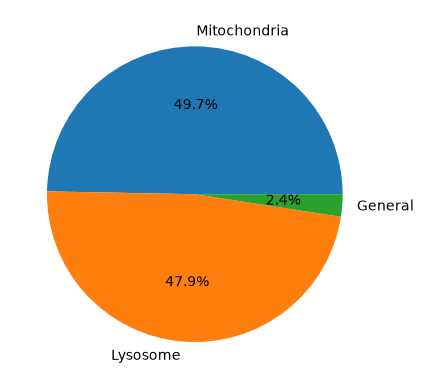

In [344]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# LRRK2 vs Control

In [345]:
lrrk2_sig_columns = []

In [347]:
for col in anova_safe_columns:
   

    # Perform ANOVA
    if col == 'Cell Type':
        print("BEGIN!")
    else:
        # Extract individual groups
        control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control']
        control = control[col]
        lrrk2 = anova_safe_data[anova_safe_data['Cell Type'] == 'LRRK2']
        lrrk2 = lrrk2[col]
        
        # val = stats.f_oneway(control, lrrk2)
        val = stats.kruskal(control, lrrk2)

        if val.pvalue < 0.05:
            lrrk2_sig_columns.append(col)
    
        print(col, ':')
        print(val)
        print("")

Lysosome Intensity - Nucleus region Mean :
KruskalResult(statistic=np.float64(3.1875901875901747), pvalue=np.float64(0.07419931719571338))

Lysosome Intensity - Nucleus region StdDev :
KruskalResult(statistic=np.float64(2.922077922077918), pvalue=np.float64(0.08737528034076734))

Lysosome Intensity - Nucleus region Median :
KruskalResult(statistic=np.float64(1.3867243867243815), pvalue=np.float64(0.23895905206052603))

Lysosome Intensity - Nucleus region Maximum :
KruskalResult(statistic=np.float64(4.6883116883116855), pvalue=np.float64(0.03036847223425402))

Lysosome Intensity - Nucleus region Minimum :
KruskalResult(statistic=np.float64(4.053391053391053), pvalue=np.float64(0.04408270855615712))

Lysosome Intensity - Nucleus region Sum :
KruskalResult(statistic=np.float64(9.467532467532465), pvalue=np.float64(0.0020914050461957145))

Lysosome Intensity - Nucleus region CV [%] :
KruskalResult(statistic=np.float64(1.3867243867243815), pvalue=np.float64(0.23895905206052603))

Lysosome I

In [350]:
print(lrrk2_sig_columns)
print(len(lrrk2_sig_columns))

['Lysosome Intensity - Nucleus region Mean', 'Lysosome Intensity - Nucleus region StdDev', 'Lysosome Intensity - Nucleus region Maximum', 'Lysosome Intensity - Nucleus region Minimum', 'Lysosome Intensity - Nucleus region Sum', 'Lysosome Intensity - Nucleus region Quantile 90%', 'General Dimension - Nucleus region Area µm²', 'General Dimension - Nucleus region Perimeter µm', 'General Dimension - Nucleus region Width µm', 'General Dimension - Nucleus region Length µm', 'Lysosome Spatial - Nucleus region Threshold Compactness 30%', 'Lysosome Spatial - Nucleus region Threshold Compactness 40%', 'Lysosome Spatial - Nucleus region Threshold Compactness 50%', 'Lysosome Dimension - Nucleus region Axial Small Length', 'Lysosome Spatial - Nucleus region Radial Mean', 'Lysosome Spatial - Nucleus region Radial Relative Deviation', 'Lysosome Spatial - Nucleus region Profile 1/2', 'Lysosome Spatial - Nucleus region Profile 2/2', 'Lysosome Spatial - Nucleus region Symmetry 03 SER-Dark', 'Lysosome Sp

In [351]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [352]:
for col in lrrk2_sig_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

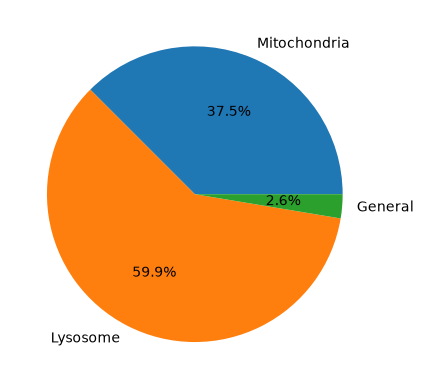

In [353]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# PRKN vs Control

In [354]:
prkn_sig_cols = []

In [355]:
for col in anova_safe_columns:
    # Extract individual groups
    # Perform ANOVA
    if col == 'Cell Type':
        print("BEGIN!")
    else:
        control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control']
        control = control[col]
        prkn = anova_safe_data[anova_safe_data['Cell Type'] == 'PRKN']
        prkn = prkn[col]
        
        # Perform ANOVA
        val = stats.kruskal(control, prkn)
        # val = stats.f_oneway(control, prkn)

        if val.pvalue < 0.05:
                prkn_sig_cols.append(col)
        
        print(col, ':')
        print(val)
        print("")

Lysosome Intensity - Nucleus region Mean :
KruskalResult(statistic=np.float64(0.0014430014430075744), pvalue=np.float64(0.9696981596092581))

Lysosome Intensity - Nucleus region StdDev :
KruskalResult(statistic=np.float64(0.0014430014430075744), pvalue=np.float64(0.9696981596092581))

Lysosome Intensity - Nucleus region Median :
KruskalResult(statistic=np.float64(0.0014430014430075744), pvalue=np.float64(0.9696981596092581))

Lysosome Intensity - Nucleus region Maximum :
KruskalResult(statistic=np.float64(0.0014430014430075744), pvalue=np.float64(0.9696981596092581))

Lysosome Intensity - Nucleus region Minimum :
KruskalResult(statistic=np.float64(0.012987012987011326), pvalue=np.float64(0.9092690452142275))

Lysosome Intensity - Nucleus region Sum :
KruskalResult(statistic=np.float64(0.32467532467531157), pvalue=np.float64(0.568811400413345))

Lysosome Intensity - Nucleus region CV [%] :
KruskalResult(statistic=np.float64(0.17460317460317754), pvalue=np.float64(0.6760528085643427))

L

In [356]:
len(prkn_sig_cols)

87

In [357]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [358]:
for col in prkn_sig_cols:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

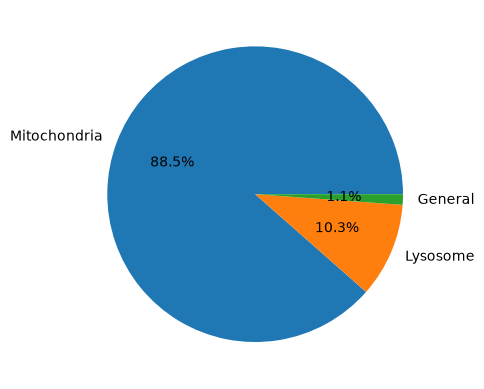

In [359]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# SNCA vs Control

In [360]:
snca_sig_cols = []

In [362]:
for col in anova_safe_columns:
    # Extract individual groups
    control = anova_safe_data[anova_safe_data['Cell Type'] == 'Control'][col]
    snca = anova_safe_data[anova_safe_data['Cell Type'] == 'SNCA'][col]
    # Perform ANOVA
    if col == 'Cell Type':
        print("DONE!")
    else:
        # Perform ANOVA
        # val = stats.f_oneway(control, snca)
        val = stats.kruskal(control, snca)
        
        if val.pvalue < 0.05:
                snca_sig_cols.append(col)
        
        print(col, ':')
        print(val)
        print("")

Lysosome Intensity - Nucleus region Mean :
KruskalResult(statistic=np.float64(2.1948051948051983), pvalue=np.float64(0.13847671503211265))

Lysosome Intensity - Nucleus region StdDev :
KruskalResult(statistic=np.float64(0.636363636363626), pvalue=np.float64(0.42503065278493135))

Lysosome Intensity - Nucleus region Median :
KruskalResult(statistic=np.float64(1.975468975468985), pvalue=np.float64(0.1598685556691316))

Lysosome Intensity - Nucleus region Maximum :
KruskalResult(statistic=np.float64(1.767676767676761), pvalue=np.float64(0.18366985885429593))

Lysosome Intensity - Nucleus region Minimum :
KruskalResult(statistic=np.float64(1.5714285714285694), pvalue=np.float64(0.20999967175560622))

Lysosome Intensity - Nucleus region Sum :
KruskalResult(statistic=np.float64(1.5714285714285694), pvalue=np.float64(0.20999967175560622))

Lysosome Intensity - Nucleus region CV [%] :
KruskalResult(statistic=np.float64(1.2135642135642115), pvalue=np.float64(0.27062738558725485))

Lysosome Inte

In [363]:
print(snca_sig_cols)
print(len(snca_sig_cols))

['Lysosome Spatial - Nucleus region Threshold Compactness 50%', 'Lysosome Spatial - Nucleus region Threshold Compactness 60%', 'Lysosome Spatial - Nucleus region Threshold Compactness 30% SER-Ridge', 'Lysosome Spatial - Inner region Symmetry 02 SER-Ridge', 'Lysosome Spatial - Inner region Symmetry 02 SER-Spot', 'Lysosome Intensity - Middle region CV [%]', 'Lysosome Texture - Middle region SER Hole 1 px', 'Lysosome Texture - Middle region SER Bright 1 px', 'Lysosome Texture - Middle region Haralick Sum Variance 2 px', 'Lysosome Texture - Middle region Haralick Homogeneity 2 px', 'Lysosome Intensity - Cell region CV [%]', 'Lysosome Spatial - Nucleus region Threshold Compactness 50%', 'Lysosome Spatial - Nucleus region Threshold Compactness 60%', 'Lysosome Spatial - Inner region Symmetry 03 SER-Dark', 'Lysosome Spatial - Inner region Symmetry 02 SER-Ridge', 'Lysosome Spatial - Inner region Symmetry 02 SER-Spot', 'Lysosome Spatial - Inner region Symmetry 13 SER-Spot', 'Lysosome Texture - I

In [364]:
pie_chart_dict = {
    'Mitochondria': 0,
    'Lysosome': 0,
    'General' :0
}

In [365]:
for col in snca_sig_cols:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]

    pie_chart_dict[organelle] += 1
    

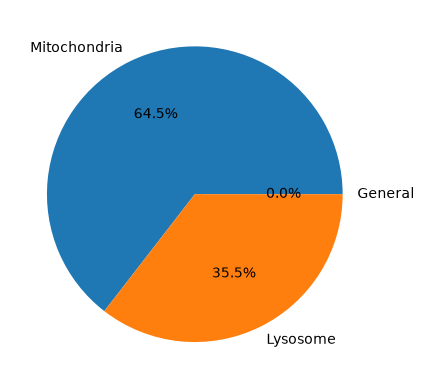

In [366]:
sizes = list(pie_chart_dict.values())
labels = list(pie_chart_dict.keys())
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

In [367]:
print("LRRK2:", lrrk2_sig_columns)

LRRK2: ['Lysosome Intensity - Nucleus region Mean', 'Lysosome Intensity - Nucleus region StdDev', 'Lysosome Intensity - Nucleus region Maximum', 'Lysosome Intensity - Nucleus region Minimum', 'Lysosome Intensity - Nucleus region Sum', 'Lysosome Intensity - Nucleus region Quantile 90%', 'General Dimension - Nucleus region Area µm²', 'General Dimension - Nucleus region Perimeter µm', 'General Dimension - Nucleus region Width µm', 'General Dimension - Nucleus region Length µm', 'Lysosome Spatial - Nucleus region Threshold Compactness 30%', 'Lysosome Spatial - Nucleus region Threshold Compactness 40%', 'Lysosome Spatial - Nucleus region Threshold Compactness 50%', 'Lysosome Dimension - Nucleus region Axial Small Length', 'Lysosome Spatial - Nucleus region Radial Mean', 'Lysosome Spatial - Nucleus region Radial Relative Deviation', 'Lysosome Spatial - Nucleus region Profile 1/2', 'Lysosome Spatial - Nucleus region Profile 2/2', 'Lysosome Spatial - Nucleus region Symmetry 03 SER-Dark', 'Lyso

In [368]:
print("PRKN", prkn_sig_cols)

PRKN ['Lysosome Spatial - Inner region Threshold Compactness 30% SER-Ridge', 'Lysosome Spatial - Inner region Symmetry 03 SER-Spot', 'Lysosome Spatial - Inner region Symmetry 13 SER-Spot', 'Lysosome Texture - Inner region Haralick Correlation 2 px', 'Lysosome Intensity - Middle region Contrast', 'Lysosome Spatial - Middle region Symmetry 15', 'Lysosome Spatial - Middle region Symmetry 04 SER-Spot', 'Lysosome Spatial - Middle region Symmetry 05 SER-Spot', 'General Dimension - Outer region Ratio Width to Length', 'Lysosome Spatial - Outer region Symmetry 05', 'Mitochondria Intensity - Nucleus region Minimum', 'Mitochondria Intensity - Nucleus region CV [%]', 'Mitochondria Spatial - Nucleus region Symmetry 05', 'Mitochondria Spatial - Nucleus region Profile 1/2 SER-Spot', 'Mitochondria Spatial - Nucleus region Threshold Compactness 30% SER-Edge', 'Mitochondria Spatial - Nucleus region Profile 1/2 SER-Edge', 'Mitochondria Texture - Nucleus region SER Spot 1 px', 'Mitochondria Texture - Nuc

In [369]:
print("SNCA", snca_sig_cols)

SNCA ['Lysosome Spatial - Nucleus region Threshold Compactness 50%', 'Lysosome Spatial - Nucleus region Threshold Compactness 60%', 'Lysosome Spatial - Nucleus region Threshold Compactness 30% SER-Ridge', 'Lysosome Spatial - Inner region Symmetry 02 SER-Ridge', 'Lysosome Spatial - Inner region Symmetry 02 SER-Spot', 'Lysosome Intensity - Middle region CV [%]', 'Lysosome Texture - Middle region SER Hole 1 px', 'Lysosome Texture - Middle region SER Bright 1 px', 'Lysosome Texture - Middle region Haralick Sum Variance 2 px', 'Lysosome Texture - Middle region Haralick Homogeneity 2 px', 'Lysosome Intensity - Cell region CV [%]', 'Lysosome Spatial - Nucleus region Threshold Compactness 50%', 'Lysosome Spatial - Nucleus region Threshold Compactness 60%', 'Lysosome Spatial - Inner region Symmetry 03 SER-Dark', 'Lysosome Spatial - Inner region Symmetry 02 SER-Ridge', 'Lysosome Spatial - Inner region Symmetry 02 SER-Spot', 'Lysosome Spatial - Inner region Symmetry 13 SER-Spot', 'Lysosome Textur

In [370]:
print("All", signifcant_columns)

All ['Lysosome Intensity - Nucleus region Maximum', 'Lysosome Intensity - Nucleus region Sum', 'General Dimension - Nucleus region Area µm²', 'General Dimension - Nucleus region Perimeter µm', 'General Dimension - Nucleus region Width µm', 'General Dimension - Nucleus region Length µm', 'Lysosome Spatial - Nucleus region Threshold Compactness 30%', 'Lysosome Spatial - Nucleus region Threshold Compactness 40%', 'Lysosome Spatial - Nucleus region Threshold Compactness 50%', 'Lysosome Dimension - Nucleus region Axial Small Length', 'Lysosome Spatial - Nucleus region Radial Mean', 'Lysosome Spatial - Nucleus region Profile 1/2', 'Lysosome Spatial - Nucleus region Profile 2/2', 'Lysosome Spatial - Nucleus region Symmetry 05 SER-Dark', 'Lysosome Spatial - Nucleus region Threshold Compactness 30% SER-Dark', 'Lysosome Spatial - Nucleus region Threshold Compactness 40% SER-Dark', 'Lysosome Texture - Nucleus region Axial Small Length SER-Dark', 'Lysosome Spatial - Nucleus region Radial Mean SER-

In [373]:
inter = list(set(signifcant_columns) & set(snca_sig_cols) & set(lrrk2_sig_columns) & set(prkn_sig_cols))

In [374]:
inter

['Mitochondria Texture - Outer region Haralick Correlation 2 px',
 'Mitochondria Texture - Nucleus region Haralick Sum Variance 2 px',
 'Mitochondria Intensity - Nucleus region CV [%]',
 'Mitochondria Texture - Outer region SER Spot 1 px',
 'Lysosome Spatial - Inner region Symmetry 13 SER-Spot',
 'Mitochondria Texture - Cell region SER Spot 1 px',
 'Mitochondria Texture - Middle region SER Spot 1 px',
 'Mitochondria Spatial - Nucleus region Threshold Compactness 30% SER-Edge']

# Check for a couple of correlations

In [375]:
batch_1 = pd.read_csv('data/cell_line_agg_data/batch_1_normalised_cellline_agg.csv') 
batch_2 = pd.read_csv('data/cell_line_agg_data/batch_2_normalised_cellline_agg.csv') 
batch_3 = pd.read_csv('data/cell_line_agg_data/batch_3_normalised_cellline_agg.csv') 
all_aggs = pd.concat([batch_1, batch_2, batch_3])
inter.append('Cell Type')
all_aggs = all_aggs[inter]
all_aggs

,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Nucleus region Haralick Sum Variance 2 px,Mitochondria Intensity - Nucleus region CV [%],Mitochondria Texture - Outer region SER Spot 1 px,Lysosome Spatial - Inner region Symmetry 13 SER-Spot,Mitochondria Texture - Cell region SER Spot 1 px,Mitochondria Texture - Middle region SER Spot 1 px,Mitochondria Spatial - Nucleus region Threshold Compactness 30% SER-Edge,Cell Type
0,1.018684,0.868990,0.922181,0.905649,1.187844,0.882138,0.880144,1.180241,PRKN
1,1.024578,1.673491,1.321052,0.885274,1.111782,0.952087,0.998792,0.903617,PRKN
2,1.003959,0.975239,0.990783,1.065721,0.983402,1.034077,1.024941,1.005531,Control
3,0.990845,0.982858,1.001291,0.998830,1.004673,1.015478,1.010454,0.994747,Control
4,1.009641,0.933985,0.965388,1.035959,1.066045,1.018388,1.003617,1.038392,SNCA
5,1.003829,1.491654,1.231730,0.755053,1.162643,0.847570,0.892817,1.051368,SNCA
6,1.034316,0.922654,0.958918,0.895884,1.041733,0.865288,0.865155,1.067817,SNCA
7,0.986789,0.805229,0.879287,0.611800,1.249477,0.698749,0.695880,1.181583,LRRK2
8,1.011650,0.932271,0.959399,0.900730,1.046047,0.882792,0.893689,1.122175,LRRK2
9,0.969276,0.731483,0.838685,0.818489,1.209368,0.856199,0.884150,1.128199,LRRK2


In [376]:
control_df = all_aggs[all_aggs['Cell Type'] == 'Control']
control_df = all_aggs.drop(columns=['Cell Type'])
control_df_corr = control_df.corr()

<Axes: >

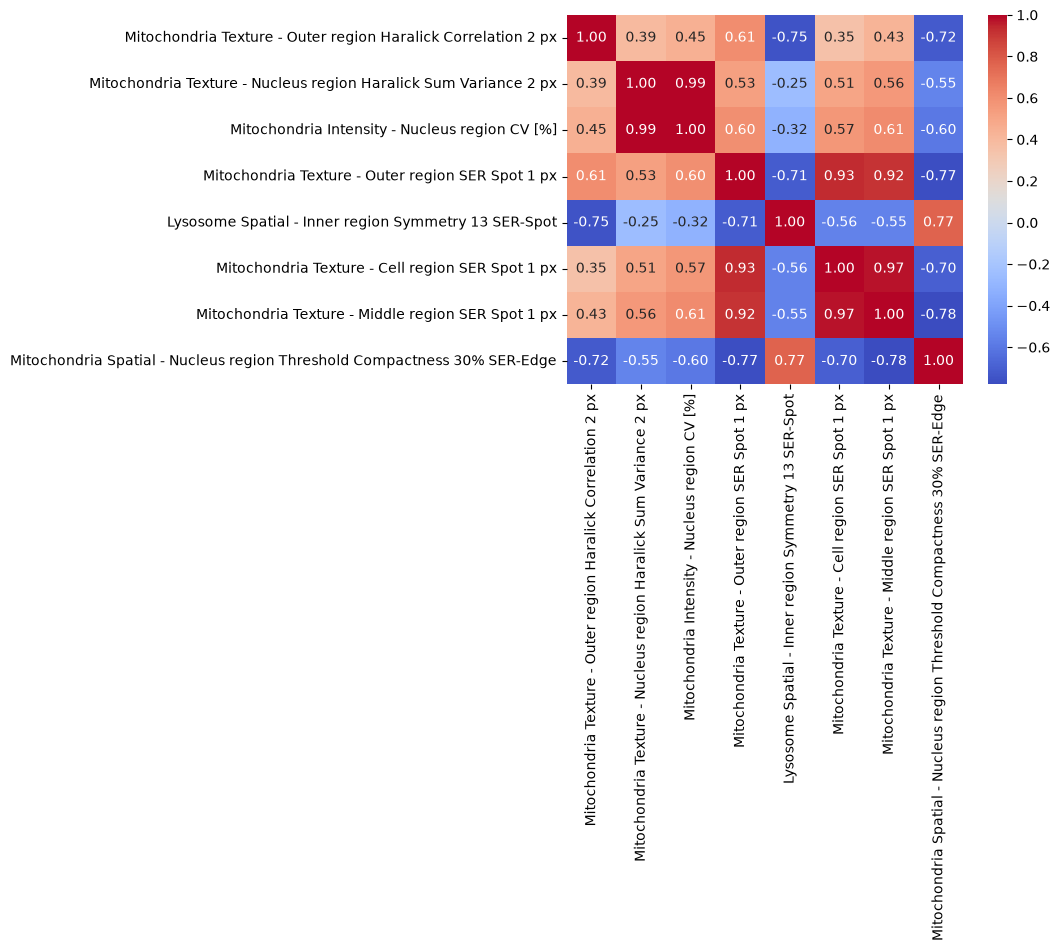

In [377]:
sns.heatmap(
    data=control_df_corr,
    annot=True, cmap='coolwarm', fmt=".2f"
)

In [378]:
control_df = all_aggs[all_aggs['Cell Type'] == 'Control']
control_df = all_aggs.drop(columns=['Cell Type'])
control_df_corr = control_df.corr()

<Axes: >

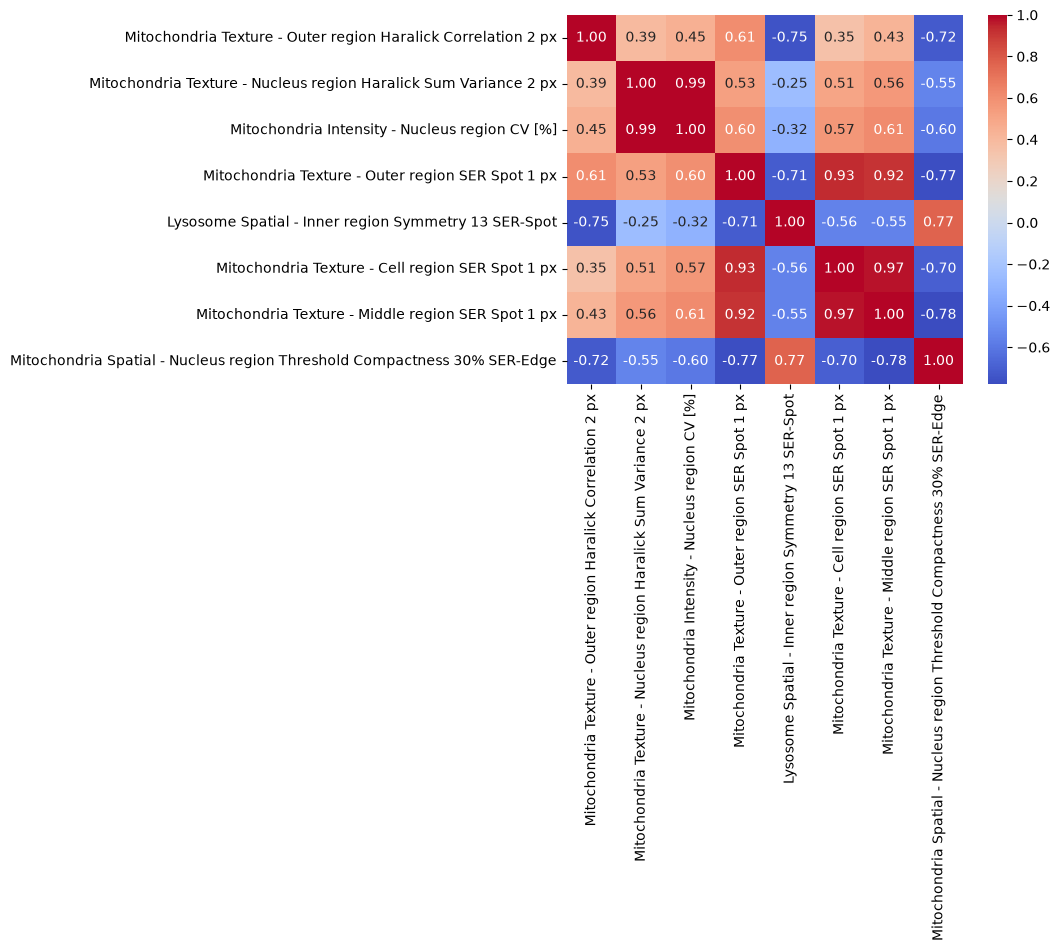

In [379]:
sns.heatmap(
    data=control_df_corr,
    annot=True, cmap='coolwarm', fmt=".2f"
)

In [380]:
def generate_corr_matrix(df, cell_type):
    cell_type_df = df[df['Cell Type'] == cell_type]
    cell_type_df = cell_type_df.drop(columns=['Cell Type'])
    cell_type_df_corr = cell_type_df.corr()

    sns.heatmap(
        data=cell_type_df_corr,
        annot=True, cmap='coolwarm', fmt=".2f"
    )

    plt.show()

SNCA


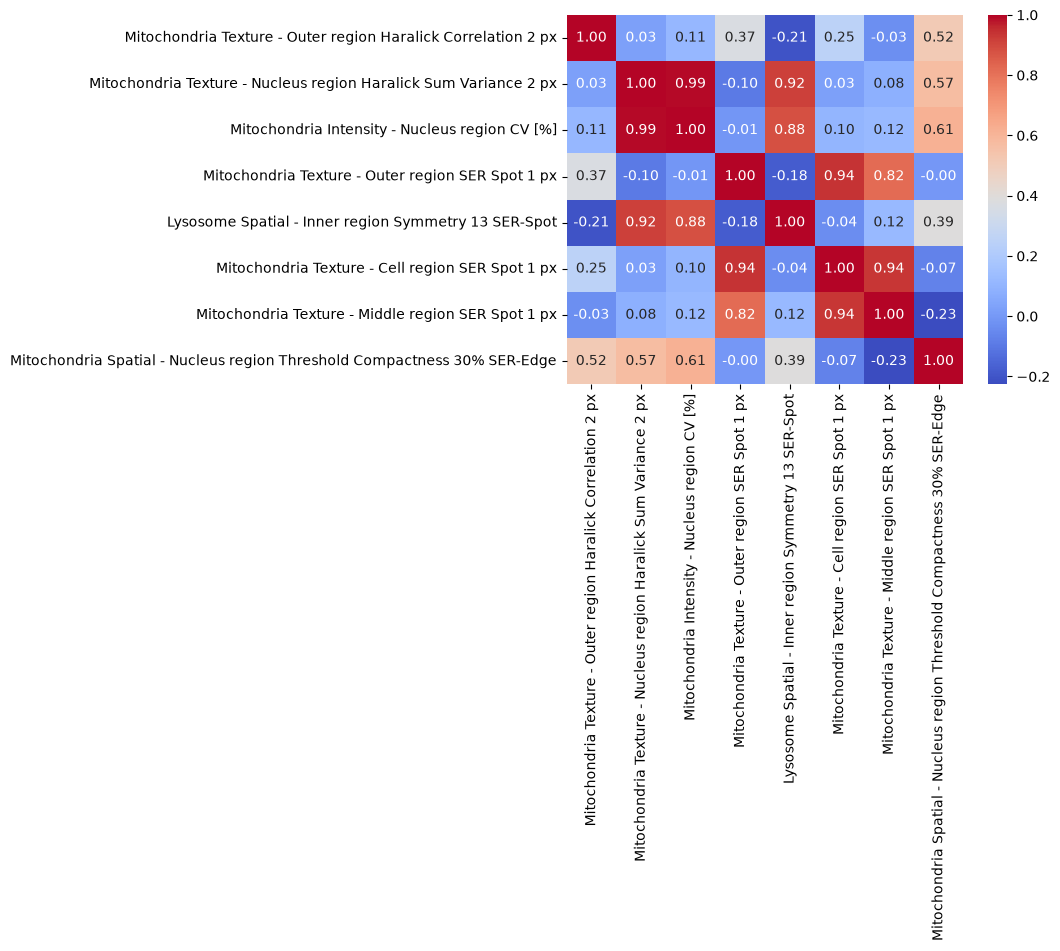

PRKN


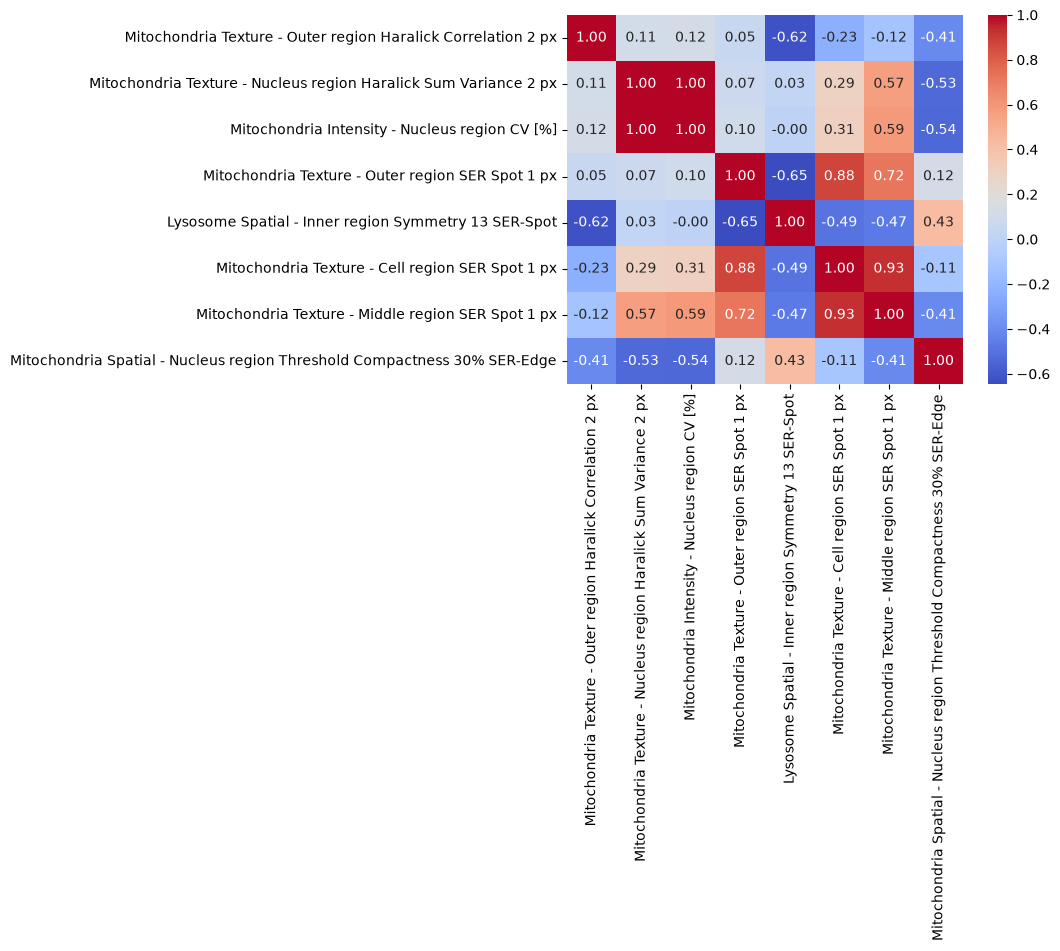

LRRK2


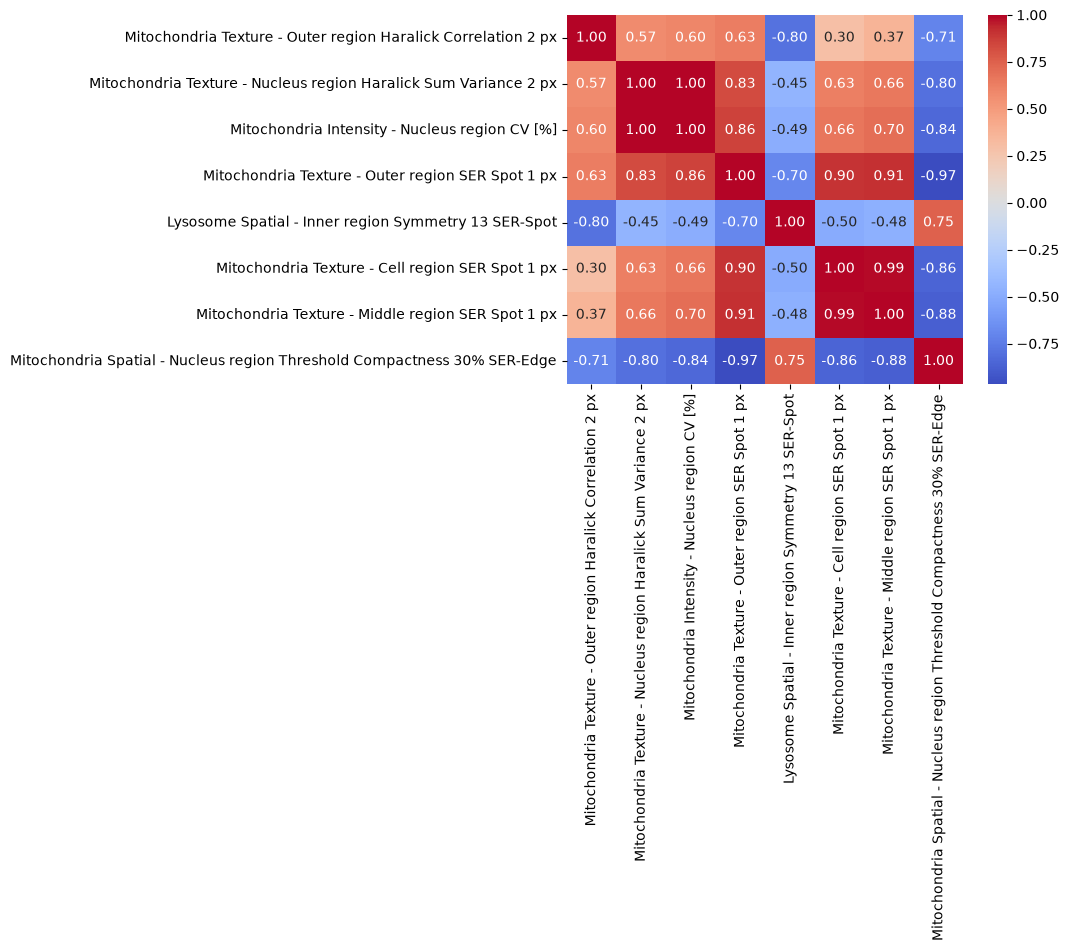

Control


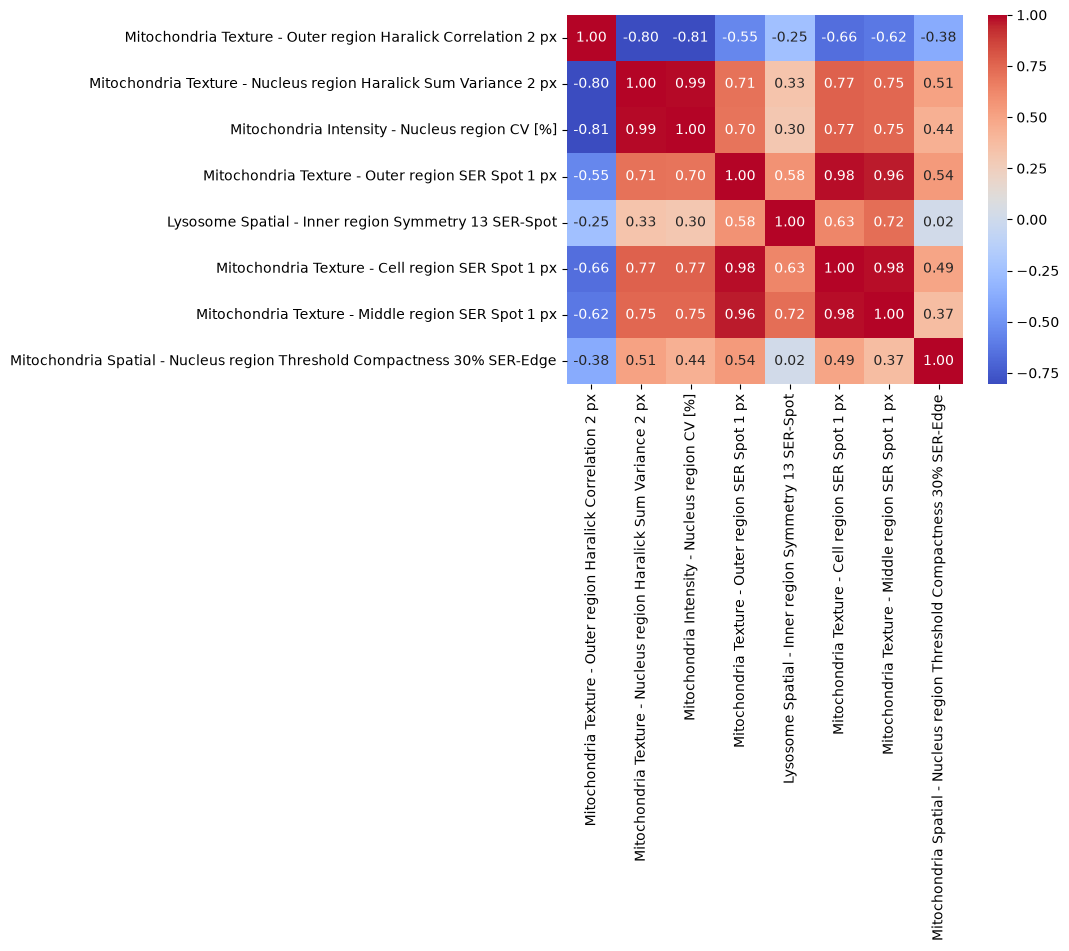

In [381]:
cell_type_set = set(counts['Cell Type'])
cell_type_set

for ct in cell_type_set:
    print(ct)
    generate_corr_matrix(
        all_aggs,
        ct
    )